# CatBoost Workspace

Отдельный ноутбук только для CatBoost.

Здесь используется изолированный модуль `model_baselines_catboost.py`, чтобы не тянуть Naive, ARIMA, SARIMA, N-BEATS и LSTM.

Поток работы:
1. загрузка и очистка данных,
2. настройка CatBoost и профиля поиска,
3. `HalvingGridSearchCV` + финальное обучение,
4. rolling 24h benchmark на minute-данных,
5. экспорт результатов.

## 1) Окружение

При необходимости раскомментируй установку пакетов и перезапусти kernel.

In [1]:
# %pip install pandas numpy requests statsmodels matplotlib seaborn scikit-learn torch tqdm catboost

import sys
print('Python:', sys.version)

Python: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]


## 2) Импорты и базовая конфигурация

Подключаем проект, включаем изолированный CatBoost-модуль и задаём общие параметры запуска.

In [2]:
import importlib

import os

from pathlib import Path

import numpy as np

import pandas as pd

import seaborn as sns

import torch

import data_pipeline as _dp

import model_baselines_catboost as _mb

from export_utils import plot_result

_dp = importlib.reload(_dp)
_mb = importlib.reload(_mb)

DataConfig = _dp.DataConfig
DataProcessor = _dp.DataProcessor
build_datasets = _dp.build_datasets
load_klines_from_sqlite = _dp.load_klines_from_sqlite
load_market_snapshots_from_sqlite = _dp.load_market_snapshots_from_sqlite
sync_market_data_to_sqlite = _dp.sync_market_data_to_sqlite

run_catboost = _mb.run_catboost
run_catboost_gridsearchcv_native_pipeline = _mb.run_catboost_gridsearchcv_native_pipeline
fit_catboost_inference_model = _mb.fit_catboost_inference_model
predict_catboost_inference = _mb.predict_catboost_inference

CPU_COUNT = int(os.cpu_count() or 8)
SAFE_CPU_WORKERS = max(1, min(16, CPU_COUNT - 1))

pd.set_option('display.max_columns', 50)
pd.set_option('display.width', 160)
sns.set_theme(style='whitegrid')

CONFIG = DataConfig(
    base_url='https://api.bybit.com',
    interval='1',
    bars=100_000,
    target_col='close',
    date_col='timestamp',
    test_ratio=0.2,
)

SYMBOLS = ['BTCUSDT', 'ETHUSDT']

OUTPUT_DIR = Path('data/outputs')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

SQLITE_DB_PATH = Path('data/market_data.sqlite')

MARKET_SNAPSHOT_ROWS = 5

print('data_pipeline module file:', Path(_dp.__file__).resolve())
print('CatBoost module file:', Path(_mb.__file__).resolve())
print('SQLite DB:', SQLITE_DB_PATH.resolve())
print('CUDA available:', torch.cuda.is_available())

if torch.cuda.is_available():
    print('GPU:', torch.cuda.get_device_name(0))

print('SAFE_CPU_WORKERS:', SAFE_CPU_WORKERS)
print(f'Data config: interval={CONFIG.interval}m | bars={CONFIG.bars:,}')

data_pipeline module file: C:\Users\zzz20\ModelLine\data_pipeline.py
CatBoost module file: C:\Users\zzz20\ModelLine\model_baselines_catboost.py
SQLite DB: C:\Users\zzz20\ModelLine\data\market_data.sqlite
CUDA available: True
GPU: NVIDIA GeForce RTX 4080
SAFE_CPU_WORKERS: 16
Data config: interval=1m | bars=100,000


## 3) Загрузка, очистка и разбиение данных

Скачиваем или читаем локальные ряды, затем очищаем и строим `full/train/test`.

In [3]:
raw_data = {}
processor = DataProcessor(target_col=CONFIG.target_col, date_col=CONFIG.date_col)
cleaned_data = {}
reports = {}
latest_snapshot_rows = []

for symbol in SYMBOLS:
    try:
        synced_df, snapshot = sync_market_data_to_sqlite(
            symbol=symbol,
            config=CONFIG,
            db_path=SQLITE_DB_PATH,
            history_bars=CONFIG.bars,
            fetch_snapshot=True,
        )
        raw_data[symbol] = load_klines_from_sqlite(
            symbol=symbol,
            interval=CONFIG.interval,
            db_path=SQLITE_DB_PATH,
            limit=CONFIG.bars,
        )
        print(
            f'{symbol}: SQLite sync complete | history_rows={len(raw_data[symbol])} | '
            f'snapshot_ts={snapshot["snapshot_ts"] if snapshot is not None else "n/a"}'
        )
    except Exception as ex:
        cached_df = load_klines_from_sqlite(
            symbol=symbol,
            interval=CONFIG.interval,
            db_path=SQLITE_DB_PATH,
            limit=CONFIG.bars,
        )
        if len(cached_df) == 0:
            raise RuntimeError(
                f'{symbol}: не удалось синхронизировать данные в SQLite и в базе нет кэша. Ошибка: {ex}'
            )
        raw_data[symbol] = cached_df
        print(f'{symbol}: sync error ({ex}), использован SQLite cache rows={len(cached_df)}')

    snapshot_df = load_market_snapshots_from_sqlite(symbol=symbol, db_path=SQLITE_DB_PATH, limit=1)
    if len(snapshot_df) > 0:
        latest_snapshot_rows.append(snapshot_df.iloc[0].to_dict())

for symbol, df in raw_data.items():
    clean_df, rep = processor.process(df)
    cleaned_data[symbol] = clean_df
    reports[symbol] = rep
    print(
        f'{symbol}: before={rep["initial_rows"]} after={rep["final_rows"]} removed={rep["removed_total"]} '
        f'(zero/nonpos={rep["removed_nonpositive_or_zero"]}, outliers={rep["removed_outliers"]})'
    )

datasets = build_datasets(cleaned_data, target_col=CONFIG.target_col, test_ratio=CONFIG.test_ratio)
for symbol, data in datasets.items():
    print(f'{symbol}: full={len(data["full"])} train={len(data["train"])} test={len(data["test"])}')

LATEST_SNAPSHOT_DF = pd.DataFrame(latest_snapshot_rows)
if len(LATEST_SNAPSHOT_DF) > 0:
    LATEST_SNAPSHOT_DF['snapshot_ts'] = pd.to_datetime(LATEST_SNAPSHOT_DF['snapshot_ts'], utc=True)
    print('\nТекущий рынок из SQLite snapshot:')
    display(LATEST_SNAPSHOT_DF[['symbol', 'snapshot_ts', 'last_price', 'bid_price', 'ask_price', 'bid_size', 'ask_size', 'spread']])

cleaned_data['BTCUSDT'].head()

BTCUSDT: SQLite sync complete | history_rows=100000 | snapshot_ts=2026-03-15 23:18:37.682000+00:00
ETHUSDT: SQLite sync complete | history_rows=100000 | snapshot_ts=2026-03-15 23:18:39.903000+00:00
BTCUSDT: before=100000 after=99553 removed=447 (zero/nonpos=0, outliers=447)
ETHUSDT: before=100000 after=99378 removed=622 (zero/nonpos=0, outliers=622)
BTCUSDT: full=99553 train=79642 test=19911
ETHUSDT: full=99378 train=79502 test=19876

Текущий рынок из SQLite snapshot:


,symbol,snapshot_ts,last_price,bid_price,ask_price,bid_size,ask_size,spread
0,BTCUSDT,2026-03-15 23:18:37.682000+00:00,72759.50,72759.00,72759.10,1.906,1.854,0.10
1,ETHUSDT,2026-03-15 23:18:39.903000+00:00,2183.41,2183.41,2183.42,5.540,34.210,0.01


,start_ms,timestamp,open,high,low,close,volume,turnover
0,1767616740000,2026-01-05 12:39:00+00:00,92854.5,92854.5,92791.0,92811.6,48.521,4.503328e+06
1,1767616800000,2026-01-05 12:40:00+00:00,92811.6,92828.4,92808.0,92808.1,19.980,1.854551e+06
2,1767616860000,2026-01-05 12:41:00+00:00,92808.1,92822.2,92788.0,92822.0,19.534,1.812921e+06
3,1767616920000,2026-01-05 12:42:00+00:00,92822.0,92822.1,92770.0,92771.7,33.595,3.117332e+06
4,1767616980000,2026-01-05 12:43:00+00:00,92771.7,92798.0,92761.3,92775.8,30.087,2.791206e+06


## 4) Конфиг эксперимента CatBoost

Здесь меняются символ, профиль поиска, scoring и параметры rolling benchmark.

In [4]:
from sklearn.model_selection import ParameterGrid

RUN_SYMBOL = 'BTCUSDT'
RUN_MODEL = 'catboost'

CATBOOST_GRID_PROFILE = 'balanced'  # quick | balanced | full
CATBOOST_SCORING = 'MAE'
CATBOOST_TIME_WEIGHT = 0.05
CATBOOST_USE_CUDA = bool(torch.cuda.is_available())
CATBOOST_GRID_N_JOBS = 1
CATBOOST_CV_SPLITS = 2
CATBOOST_HALVING_FACTOR = 4
CATBOOST_SEARCH_MIN_POINTS = 512
CATBOOST_SEARCH_MAX_POINTS = 4_096
CATBOOST_TUNING_POINTS = 16_384  # последние N точек только для подбора; финальная модель ниже обучается на полном train

LIVE_MONITOR_ENABLED = False
LIVE_TRAIN_MINUTES = 40_000
LIVE_FORECAST_HORIZON_MINUTES = 60
LIVE_RETRAIN_EVERY_MINUTES = 60
LIVE_SYNC_BUFFER = 240
LIVE_POLL_SECONDS = 60
LIVE_MAX_CYCLES = None  # None = endless loop until interrupted manually
LIVE_FORCE_CPU = False

# Trading fee config. Percent values are expressed in pct units, not fractions.
LIVE_MARKET_TYPE = 'perpetual_futures'  # spot | perpetual_futures | options
LIVE_FEE_SCHEDULES = {
    'spot': {'taker_pct': 0.10, 'maker_pct': 0.10},
    'perpetual_futures': {'taker_pct': 0.06, 'maker_pct': 0.01},
    'options': {'taker_pct': 0.03, 'maker_pct': 0.03},
}
if LIVE_MARKET_TYPE not in LIVE_FEE_SCHEDULES:
    raise ValueError(f'Unknown LIVE_MARKET_TYPE: {LIVE_MARKET_TYPE}')
LIVE_FEE_CONFIG = LIVE_FEE_SCHEDULES[LIVE_MARKET_TYPE]
LIVE_MAX_SIDE_FEE_PCT = float(max(LIVE_FEE_CONFIG['taker_pct'], LIVE_FEE_CONFIG['maker_pct']))
LIVE_ROUND_TRIP_COST_PCT = float(LIVE_MAX_SIDE_FEE_PCT * 2.0)  # max fee on entry + max fee on exit
LIVE_MIN_EDGE_PCT = 0.08         # minimum net edge after costs to allow entry
LIVE_CONFIRM_1M_PCT = 0.01       # 1-minute forecast must confirm direction
LIVE_STOP_LOSS_PCT = 0.35
LIVE_TAKE_PROFIT_PCT = 0.60
LIVE_SIGNAL_HORIZONS = [1, 5, 10, 15, 30, 60]
LIVE_PULLBACK_ENTRY_PCT = 0.03   # short-term pullback magnitude before recovery
LIVE_REVERSAL_CONFIRM_PCT = 0.05 # medium horizon must reverse enough to treat as dip/rally entry
LIVE_ENTRY_MIN_MOVE_PCT = 0.03   # минимальный модуль 60m-прогноза, ниже которого вход не рассматривается
LIVE_ENTRY_RELATIVE_STRENGTH = 0.75  # адаптивный порог как доля от типичного масштаба прогнозов 10m/30m/60m
LIVE_EFFECTIVE_COST_CAP_RATIO = 0.50  # для слабых моделей не учитывать в signal gate весь round-trip cost целиком
LIVE_PULLBACK_FRACTION_OF_REQUIRED = 0.50  # pullback-порог как доля от адаптивного required_move
LIVE_REVERSAL_FRACTION_OF_REQUIRED = 0.50  # reversal-порог как доля от адаптивного required_move

PAPER_TRADING_ENABLED = True
PAPER_LEVERAGE = 1.0
PAPER_INITIAL_CAPITAL = 10_000.0
PAPER_ENTRY_FRACTION = 0.10
PAPER_DCA_FRACTION = 0.10
PAPER_MAX_DCA_COUNT = 3
PAPER_DCA_STEP_PCT = 0.20
PAPER_CLOSE_ON_SIGNAL_FLIP = True
PAPER_CLOSE_ON_MODEL_EXPIRY = True

train = datasets[RUN_SYMBOL]['train']
test = datasets[RUN_SYMBOL]['test']
full = datasets[RUN_SYMBOL]['full']

if CATBOOST_TUNING_POINTS is None or int(CATBOOST_TUNING_POINTS) <= 0:
    tuning_full = full.reset_index(drop=True)
else:
    tuning_full = full.iloc[-min(len(full), int(CATBOOST_TUNING_POINTS)):].reset_index(drop=True)

ALL_RESULTS = {}
TRAINED_MODELS = {}

def _compute_signal_thresholds(horizon_forecasts: dict[str, float]) -> dict[str, float]:
    scale_values = [
        abs(float(horizon_forecasts.get(f'move_{int(horizon)}m_pct', float('nan'))))
        for horizon in [10, 30, 60]
    ]
    scale_values = [value for value in scale_values if np.isfinite(value)]

    forecast_scale_pct = float(np.median(scale_values)) if len(scale_values) > 0 else 0.0
    required_move_pct = float(max(LIVE_ENTRY_MIN_MOVE_PCT, forecast_scale_pct * LIVE_ENTRY_RELATIVE_STRENGTH))
    effective_cost_pct = float(min(LIVE_ROUND_TRIP_COST_PCT, required_move_pct * LIVE_EFFECTIVE_COST_CAP_RATIO))
    entry_trigger_move_pct = float(max(required_move_pct, effective_cost_pct))
    adaptive_pullback_pct = float(max(LIVE_PULLBACK_ENTRY_PCT * 0.50, required_move_pct * LIVE_PULLBACK_FRACTION_OF_REQUIRED))
    adaptive_reversal_pct = float(max(LIVE_CONFIRM_1M_PCT, min(LIVE_REVERSAL_CONFIRM_PCT, required_move_pct * LIVE_REVERSAL_FRACTION_OF_REQUIRED)))

    return {
        'forecast_scale_pct': forecast_scale_pct,
        'required_move_pct': required_move_pct,
        'effective_cost_pct': effective_cost_pct,
        'entry_trigger_move_pct': entry_trigger_move_pct,
        'adaptive_pullback_pct': adaptive_pullback_pct,
        'adaptive_reversal_pct': adaptive_reversal_pct,
    }

def _singleton_grid(anchor):
    return {key: [value] for key, value in anchor.items()}

def _non_anchor_values(values, anchor_value):
    return [value for value in values if value != anchor_value]

def _build_catboost_coverage_grid(full_values, anchor):
    blocks = [
        {**_singleton_grid(anchor), 'context_len': _non_anchor_values(full_values['context_len'], anchor['context_len'])},
        {**_singleton_grid(anchor), 'depth': _non_anchor_values(full_values['depth'], anchor['depth'])},
        {**_singleton_grid(anchor), 'learning_rate': _non_anchor_values(full_values['learning_rate'], anchor['learning_rate'])},
        {**_singleton_grid(anchor), 'iterations': _non_anchor_values(full_values['iterations'], anchor['iterations'])},
        {**_singleton_grid(anchor), 'l2_leaf_reg': _non_anchor_values(full_values['l2_leaf_reg'], anchor['l2_leaf_reg'])},
        _singleton_grid(anchor),
    ]
    return [block for block in blocks if all(len(values) > 0 for values in block.values())]

GRID_PROFILES = {
    'quick': {
        'context_len': [72],
        'depth': [6],
        'learning_rate': [0.05],
        'iterations': [160],
        'l2_leaf_reg': [3.0],
        'use_cuda': [CATBOOST_USE_CUDA],
    },
    'balanced': [
        {
            'context_len': [72, 120, 168],
            'depth': [8],
            'learning_rate': [0.04],
            'iterations': [280],
            'l2_leaf_reg': [3.0],
            'use_cuda': [CATBOOST_USE_CUDA],
        },
        {
            'context_len': [120],
            'depth': [6, 8, 10],
            'learning_rate': [0.04],
            'iterations': [280],
            'l2_leaf_reg': [3.0],
            'use_cuda': [CATBOOST_USE_CUDA],
        },
        {
            'context_len': [120],
            'depth': [8],
            'learning_rate': [0.03, 0.04, 0.05],
            'iterations': [160, 280, 420],
            'l2_leaf_reg': [3.0, 5.0],
            'use_cuda': [CATBOOST_USE_CUDA],
        },
    ],
    'full': _build_catboost_coverage_grid(
        full_values={
            'context_len': [72, 120, 168],
            'depth': [6, 8, 10],
            'learning_rate': [0.03, 0.04, 0.05],
            'iterations': [160, 280, 420],
            'l2_leaf_reg': [3.0, 5.0],
        },
        anchor={
            'context_len': 120,
            'depth': 8,
            'learning_rate': 0.04,
            'iterations': 280,
            'l2_leaf_reg': 3.0,
            'use_cuda': CATBOOST_USE_CUDA,
        },
    ),
}

if CATBOOST_GRID_PROFILE not in GRID_PROFILES:
    raise ValueError(f'Unknown CATBOOST_GRID_PROFILE: {CATBOOST_GRID_PROFILE}')

CATBOOST_PARAM_GRID = GRID_PROFILES[CATBOOST_GRID_PROFILE]
CATBOOST_PARAM_GRID_CANDIDATES = len(ParameterGrid(CATBOOST_PARAM_GRID))

print(f'RUN_SYMBOL={RUN_SYMBOL} | full={len(full)} | tuning_full={len(tuning_full)} | final_train={len(train)} | final_test={len(test)}')
print(f'CatBoost grid profile: {CATBOOST_GRID_PROFILE}')
print('CatBoost device:', torch.cuda.get_device_name(0) if CATBOOST_USE_CUDA else 'cpu')
print(
    f'CatBoost config: use_cuda={CATBOOST_USE_CUDA}, n_jobs={CATBOOST_GRID_N_JOBS}, ' +
    f'cv_splits={CATBOOST_CV_SPLITS}, candidates={CATBOOST_PARAM_GRID_CANDIDATES}'
)
print(
    f'CatBoost search: tuning_points={len(tuning_full)}, min_points={CATBOOST_SEARCH_MIN_POINTS}, ' +
    f'max_points={CATBOOST_SEARCH_MAX_POINTS}, factor={CATBOOST_HALVING_FACTOR}, ' +
    f'scoring={CATBOOST_SCORING}, time_weight={CATBOOST_TIME_WEIGHT}'
)
print(
    f'Live config: enabled={LIVE_MONITOR_ENABLED}, train_minutes={LIVE_TRAIN_MINUTES}, horizon_minutes={LIVE_FORECAST_HORIZON_MINUTES}, ' +
    f'retrain_every={LIVE_RETRAIN_EVERY_MINUTES}, poll_seconds={LIVE_POLL_SECONDS}, max_cycles={LIVE_MAX_CYCLES}'
)
print(
    f'Trading config: market_type={LIVE_MARKET_TYPE}, max_side_fee_pct={LIVE_MAX_SIDE_FEE_PCT}, ' +
    f'round_trip_cost_pct={LIVE_ROUND_TRIP_COST_PCT}, min_edge_pct={LIVE_MIN_EDGE_PCT}, ' +
    f'entry_min_move_pct={LIVE_ENTRY_MIN_MOVE_PCT}, confirm_1m_pct={LIVE_CONFIRM_1M_PCT}, ' +
    f'stop_loss_pct={LIVE_STOP_LOSS_PCT}, take_profit_pct={LIVE_TAKE_PROFIT_PCT}'
)
print(
    f'Signal horizons={LIVE_SIGNAL_HORIZONS}, pullback_entry_pct={LIVE_PULLBACK_ENTRY_PCT}, ' +
    f'reversal_confirm_pct={LIVE_REVERSAL_CONFIRM_PCT}, entry_relative_strength={LIVE_ENTRY_RELATIVE_STRENGTH}, ' +
    f'effective_cost_cap_ratio={LIVE_EFFECTIVE_COST_CAP_RATIO}'
)
print(
    f'Paper trading: enabled={PAPER_TRADING_ENABLED}, leverage={PAPER_LEVERAGE}, initial_capital={PAPER_INITIAL_CAPITAL}, ' +
    f'entry_fraction={PAPER_ENTRY_FRACTION}, dca_fraction={PAPER_DCA_FRACTION}, ' +
    f'max_dca={PAPER_MAX_DCA_COUNT}, dca_step_pct={PAPER_DCA_STEP_PCT}'
)
CATBOOST_PARAM_GRID

RUN_SYMBOL=BTCUSDT | full=99553 | tuning_full=16384 | final_train=79642 | final_test=19911
CatBoost grid profile: balanced
CatBoost device: NVIDIA GeForce RTX 4080
CatBoost config: use_cuda=True, n_jobs=1, cv_splits=2, candidates=24
CatBoost search: tuning_points=16384, min_points=512, max_points=4096, factor=4, scoring=MAE, time_weight=0.05
Live config: enabled=False, train_minutes=40000, horizon_minutes=60, retrain_every=60, poll_seconds=60, max_cycles=None
Trading config: market_type=perpetual_futures, max_side_fee_pct=0.06, round_trip_cost_pct=0.12, min_edge_pct=0.08, entry_min_move_pct=0.03, confirm_1m_pct=0.01, stop_loss_pct=0.35, take_profit_pct=0.6
Signal horizons=[1, 5, 10, 15, 30, 60], pullback_entry_pct=0.03, reversal_confirm_pct=0.05, entry_relative_strength=0.75, effective_cost_cap_ratio=0.5
Paper trading: enabled=True, leverage=1.0, initial_capital=10000.0, entry_fraction=0.1, dca_fraction=0.1, max_dca=3, dca_step_pct=0.2


[{'context_len': [72, 120, 168],
  'depth': [8],
  'learning_rate': [0.04],
  'iterations': [280],
  'l2_leaf_reg': [3.0],
  'use_cuda': [True]},
 {'context_len': [120],
  'depth': [6, 8, 10],
  'learning_rate': [0.04],
  'iterations': [280],
  'l2_leaf_reg': [3.0],
  'use_cuda': [True]},
 {'context_len': [120],
  'depth': [8],
  'learning_rate': [0.03, 0.04, 0.05],
  'iterations': [160, 280, 420],
  'l2_leaf_reg': [3.0, 5.0],
  'use_cuda': [True]}]

## 5) Подбор гиперпараметров и финальное обучение

Запускаем `HalvingGridSearchCV`, сохраняем лучшую конфигурацию и обучаем inference-модель CatBoost.

In [5]:
import json

CATBOOST_PARAMS_CACHE_ENABLED = True
CATBOOST_FORCE_RECOMPUTE_BEST_PARAMS = False
CATBOOST_PARAMS_CACHE_FILE = OUTPUT_DIR / f"{RUN_SYMBOL}_catboost_best_params_{CATBOOST_GRID_PROFILE}.json"

print(f'CatBoost params cache file: {CATBOOST_PARAMS_CACHE_FILE.resolve()}')
print(f'Cache enabled: {CATBOOST_PARAMS_CACHE_ENABLED} | Force recompute: {CATBOOST_FORCE_RECOMPUTE_BEST_PARAMS}')

CatBoost params cache file: C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_catboost_best_params_balanced.json
Cache enabled: True | Force recompute: False


CatBoost params cache HIT: C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_catboost_best_params_balanced.json
Grid search skipped because cached params were found.
Cell 12 training mode: inference
CatBoost tuning points: 16384
CatBoost final inference train points: 79642
CatBoost split info: {'cache_hit': True, 'cache_file': 'data\\outputs\\BTCUSDT_catboost_best_params_balanced.json', 'cache_saved_at_utc': '2026-03-15T23:12:21.488518+00:00', 'search_skipped': True, 'test_ratio': 0.2, 'tuning_points': 16384}
CatBoost best params: {'context_len': 120, 'depth': 8, 'iterations': 160, 'l2_leaf_reg': 5.0, 'learning_rate': 0.03, 'use_cuda': True}
CatBoost metrics: {'MAE': 36.62667461625144, 'RMSE': 53.54779713170333, 'MAPE': 0.05258680705726535}


,param_context_len,param_depth,param_learning_rate,param_iterations,param_l2_leaf_reg,cache_hit,cached_at_utc
0,120,8,0.03,160,5.0,True,2026-03-15T23:12:21.488518+00:00


,y_true,y_pred
0,66166.4,66170.038727
1,66166.4,66168.229817
2,66177.0,66168.809847
3,66259.9,66177.432615
4,66343.5,66259.577015


,y_true,y_pred
19906,72963.1,72913.850813
19907,73036.8,72961.679060
19908,73034.9,73036.032367
19909,72828.4,73035.838213
19910,72748.1,72828.815970


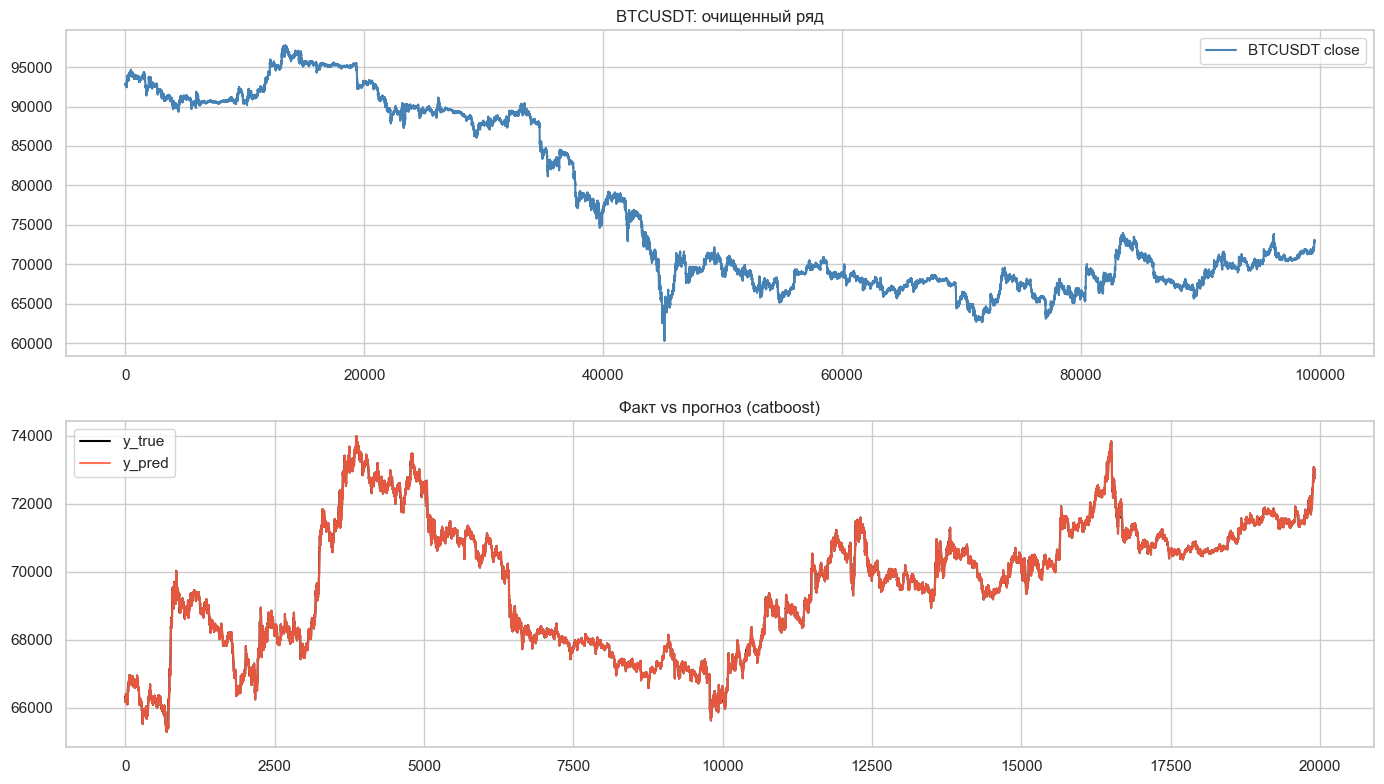

In [6]:
cache_file = Path(CATBOOST_PARAMS_CACHE_FILE)
force_recompute = bool(CATBOOST_FORCE_RECOMPUTE_BEST_PARAMS)
cache_enabled = bool(CATBOOST_PARAMS_CACHE_ENABLED)

cache_hit = cache_enabled and cache_file.exists() and not force_recompute

if cache_hit:
    with cache_file.open('r', encoding='utf-8') as f:
        cached_payload = json.load(f)

    catboost_best_params = dict(cached_payload['best_params'])
    catboost_best_params['context_len'] = int(catboost_best_params['context_len'])
    catboost_best_params['depth'] = int(catboost_best_params['depth'])
    catboost_best_params['learning_rate'] = float(catboost_best_params['learning_rate'])
    catboost_best_params['iterations'] = int(catboost_best_params['iterations'])
    catboost_best_params['l2_leaf_reg'] = float(catboost_best_params.get('l2_leaf_reg', 3.0))
    catboost_best_params['use_cuda'] = bool(catboost_best_params.get('use_cuda', CATBOOST_USE_CUDA))

    catboost_cv_df = pd.DataFrame([
        {
            'cache_hit': True,
            'cached_at_utc': cached_payload.get('saved_at_utc'),
            'param_context_len': catboost_best_params['context_len'],
            'param_depth': catboost_best_params['depth'],
            'param_learning_rate': catboost_best_params['learning_rate'],
            'param_iterations': catboost_best_params['iterations'],
            'param_l2_leaf_reg': catboost_best_params['l2_leaf_reg'],
            'param_use_cuda': catboost_best_params['use_cuda'],
        }
    ])

    catboost_split_info = {
        'cache_hit': True,
        'cache_file': str(cache_file),
        'cache_saved_at_utc': cached_payload.get('saved_at_utc'),
        'search_skipped': True,
        'test_ratio': float(CONFIG.test_ratio),
        'tuning_points': int(len(tuning_full)),
    }

    print(f'CatBoost params cache HIT: {cache_file.resolve()}')
    print('Grid search skipped because cached params were found.')
else:
    catboost_best_params, catboost_cv_df, model_metrics, pred_df, catboost_split_info = run_catboost_gridsearchcv_native_pipeline(
        full_series=tuning_full,
        param_grid=CATBOOST_PARAM_GRID,
        test_ratio=CONFIG.test_ratio,
        n_splits=CATBOOST_CV_SPLITS,
        scoring=CATBOOST_SCORING,
        use_cuda=CATBOOST_USE_CUDA,
        n_jobs=CATBOOST_GRID_N_JOBS,
        min_resource_points=CATBOOST_SEARCH_MIN_POINTS,
        max_resource_points=CATBOOST_SEARCH_MAX_POINTS,
        halving_factor=CATBOOST_HALVING_FACTOR,
        aggressive_elimination=True,
        time_weight=CATBOOST_TIME_WEIGHT,
    )

    if cache_enabled:
        cache_file.parent.mkdir(parents=True, exist_ok=True)
        cache_payload = {
            'saved_at_utc': pd.Timestamp.now(tz='UTC').isoformat(),
            'symbol': RUN_SYMBOL,
            'grid_profile': CATBOOST_GRID_PROFILE,
            'scoring': CATBOOST_SCORING,
            'best_params': catboost_best_params,
        }
        with cache_file.open('w', encoding='utf-8') as f:
            json.dump(cache_payload, f, ensure_ascii=False, indent=2)
        print(f'CatBoost params cache saved: {cache_file.resolve()}')

TRAINED_MODELS[RUN_MODEL] = fit_catboost_inference_model(
    train,
    context_len=int(catboost_best_params['context_len']),
    depth=int(catboost_best_params['depth']),
    learning_rate=float(catboost_best_params['learning_rate']),
    iterations=int(catboost_best_params['iterations']),
    l2_leaf_reg=float(catboost_best_params.get('l2_leaf_reg', 3.0)),
    use_cuda=bool(catboost_best_params.get('use_cuda', CATBOOST_USE_CUDA)),
)

model_metrics, pred_df = predict_catboost_inference(
    TRAINED_MODELS[RUN_MODEL],
    train=train,
    test=test,
)

ALL_RESULTS[RUN_MODEL] = {
    'metrics': model_metrics,
    'pred_df': pred_df.copy(),
    'symbol': RUN_SYMBOL,
}

cv_preview_cols = [
    col for col in [
        'score',
        'score_std',
        'param_context_len',
        'param_depth',
        'param_learning_rate',
        'param_iterations',
        'param_l2_leaf_reg',
        'iter',
        'rank_test_score',
        'cache_hit',
        'cached_at_utc',
    ] if col in catboost_cv_df.columns
]

print('Cell 12 training mode: inference')
print('CatBoost tuning points:', len(tuning_full))
print('CatBoost final inference train points:', len(train))
print('CatBoost split info:', catboost_split_info)
print('CatBoost best params:', catboost_best_params)
print('CatBoost metrics:', model_metrics)
display(catboost_cv_df[cv_preview_cols].head(20) if cv_preview_cols else catboost_cv_df.head(20))
display(pred_df.head())
display(pred_df.tail())
plot_result(RUN_SYMBOL, RUN_MODEL, full, pred_df)

## 6) Backtest торговли на истории

Запускаем walk-forward backtest: выбираем старт `X` дней назад, перед каждой торговой точкой обучаем или переобучаем модель на предыдущих `40 000` minute-баров и дальше принимаем решения `long/short/close/DCA` по тем же правилам, что и в live-режиме.

В выводе отображается только журнал торговых действий.

Backtest C-entry config: horizon=180m | move_pct>=0.001%
Backtest forecast mode: cell12_teacher_forced
Backtest quick-exit: enabled=True | minute=500
Backtest symbol=BTCUSDT | start_days_ago=30 | duration_days=30
Train minutes=40000 | retrain_every_hours=168 | eval_step_minutes=1
Mode=long_only | initial_capital=1000.00 | entry_fraction=0.25 | execution_fee_pct=0.0600
Scenario start | mode=long_only | capital=1000.00 | entry_fraction=0.25 | fee_pct=0.0600 | retrain_every=168h | forecast_mode=cell12_teacher_forced | from=2026-02-13 23:18:00+00:00 | to=2026-03-15 23:18:00+00:00 | steps=43067
Retrained model | ts=2026-02-13 23:18:00+00:00 | retrain_every=168h | trade_actions=0
Trade action | ts=2026-02-13 23:18:00+00:00 | action=open_long | side=long | signal_type=enter_long_C | price=68874.6000 | qty=0.00362761 | realized_pnl=0.00 | free_cash=750.00 | invested_cash=250.00 | current_pnl=-0.15 | grid_pnl=-0.15 | equity=999.85 | reason=enter long C: forecast reached +0.299% on minute 97 wit

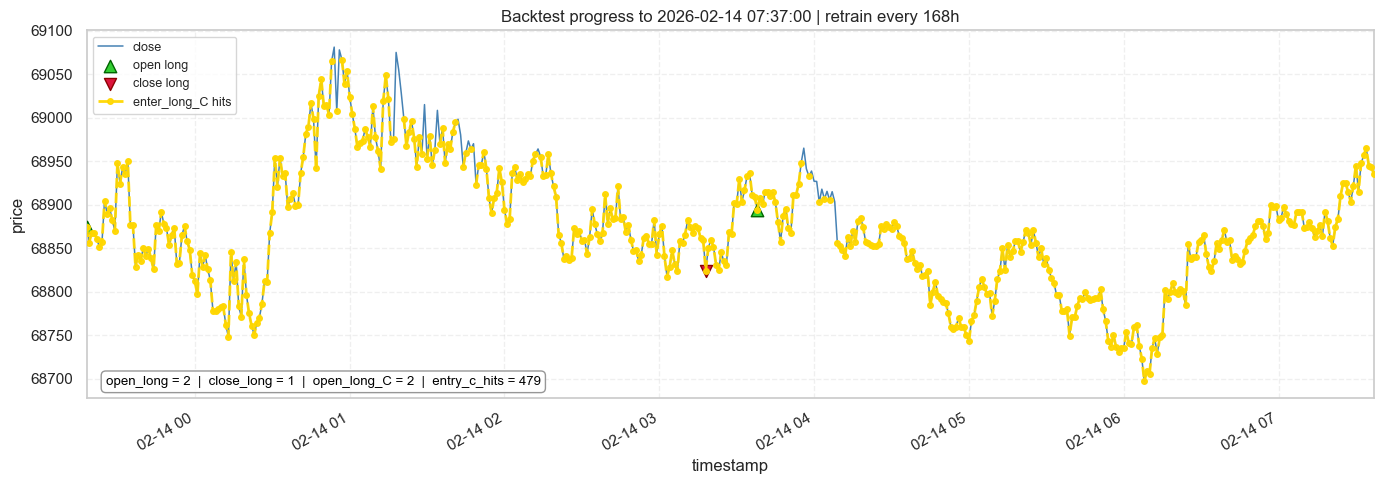

Quick exit reached at minute=500 (limit=500) | ts=2026-02-14 07:38:00+00:00 | stopping backtest loop.
Trade action | ts=2026-03-15 23:18:00+00:00 | action=close_long | side=long | signal_type=enter_long_C | price=72748.1000 | qty=0.00362536 | realized_pnl=13.66 | free_cash=1013.48 | invested_cash=0.00 | current_pnl=0.00 | grid_pnl=13.18 | equity=1013.48 | reason=backtest_end

Backtest scenarios:


,retrain_hours,requested_start_ts,requested_end_ts,actual_start_ts,actual_end_ts,effective_duration_days,eval_step_minutes,initial_capital,entry_fraction,execution_fee_pct,trade_actions,closed_trades,opened_longs,entry_c_checks,entry_c_hits,entry_c_hit_rate,entry_c_horizon_minutes,entry_c_move_pct,quick_exit_enabled,quick_exit_minute,ending_equity,ending_realized_pnl
0,168,2026-02-13 23:18:00+00:00,2026-03-15 23:18:00+00:00,2026-02-13 23:18:00+00:00,2026-03-15 23:18:00+00:00,30.0,1,1000.0,0.25,0.06,4,2,2,500,479,0.958,180,0.001,True,500,1013.480522,13.180572



Дни без торгов:


,retrain_hours,date,trade_actions,status
0,168,2026-02-15 00:00:00+00:00,0,нет торгов
1,168,2026-02-16 00:00:00+00:00,0,нет торгов
2,168,2026-02-17 00:00:00+00:00,0,нет торгов
3,168,2026-02-18 00:00:00+00:00,0,нет торгов
4,168,2026-02-19 00:00:00+00:00,0,нет торгов
5,168,2026-02-20 00:00:00+00:00,0,нет торгов
6,168,2026-02-21 00:00:00+00:00,0,нет торгов
7,168,2026-02-22 00:00:00+00:00,0,нет торгов
8,168,2026-02-23 00:00:00+00:00,0,нет торгов
9,168,2026-02-24 00:00:00+00:00,0,нет торгов



Trades shown: last 4 rows (full log is saved to CSV if enabled).


,retrain_hours,timestamp,action,side,signal_type,price,qty,cash_flow,realized_pnl,free_cash_after,equity_after,reason
0,168,2026-02-13 23:18:00+00:00,open_long,long,enter_long_C,68874.6,0.003628,-250.000000,NaN,750.000000,999.850090,enter long C: forecast reached +0.299% on minu...
1,168,2026-02-14 03:18:00+00:00,close_long,long,enter_long_C,68824.4,0.003628,249.668093,-0.481907,999.668093,999.668093,max_hold_reached
2,168,2026-02-14 03:38:00+00:00,open_long,long,enter_long_C,68894.5,0.003625,-249.917023,NaN,749.751070,999.518233,enter long C: forecast reached +0.102% on minu...
3,168,2026-03-15 23:18:00+00:00,close_long,long,enter_long_C,72748.1,0.003625,263.729452,13.662478,1013.480522,1013.480522,backtest_end



Saved backtest trades to:
C:\Users\zzz20\ModelLine\data\outputs\BTCUSDT_catboost_backtest_trades_20260315_231955.csv
Forecast history rows: 500


,timestamp,current_price,forecast_horizon_minutes,forecast_mode
495,2026-02-14 07:33:00+00:00,68956.6,180,cell12_teacher_forced
496,2026-02-14 07:34:00+00:00,68964.8,180,cell12_teacher_forced
497,2026-02-14 07:35:00+00:00,68944.9,180,cell12_teacher_forced
498,2026-02-14 07:36:00+00:00,68942.9,180,cell12_teacher_forced
499,2026-02-14 07:37:00+00:00,68935.2,180,cell12_teacher_forced


In [ ]:
import importlib
from IPython.display import display

import catboost_backtest as _cb_backtest
import model_baselines_catboost as _mb

_cb_backtest = importlib.reload(_cb_backtest)
_mb = importlib.reload(_mb)

BacktestConfig = _cb_backtest.BacktestConfig
run_backtest_block = _cb_backtest.run_backtest_block

BACKTEST_ENABLED = True  # Включить или выключить backtest-блок
BACKTEST_START_DAYS_AGO = 30  # За сколько дней до конца истории начинается окно теста
BACKTEST_DURATION_DAYS = 30  # Длина тестового окна в днях
BACKTEST_TRAIN_MINUTES = 40_000  # Размер обучающего окна перед каждой точкой теста
BACKTEST_RETRAIN_EVERY_HOURS = 168  # Частота переобучения модели в backtest
BACKTEST_FORCE_CPU = LIVE_FORCE_CPU  # Принудительно использовать CPU в backtest
BACKTEST_SAVE_TO_CSV = True  # Сохранять журнал действий в CSV
BACKTEST_DISPLAY_MAX_TRADES = 100  # Сколько последних действий выводить в notebook
BACKTEST_EVAL_EVERY_MINUTES = 1  # Шаг прохода по минутной истории

BACKTEST_QUICK_EXIT_ENABLED = True  # Быстрый выход из цикла backtest
BACKTEST_QUICK_EXIT_MINUTE = 500  # Остановить цикл при достижении этой минуты от старта окна

BACKTEST_ENABLE_TRADE_EXECUTION = False  # False: не открывать/не закрывать сделки, считать только прогнозы и диагностику

BACKTEST_INITIAL_CAPITAL = 1_000.0  # Стартовый виртуальный капитал в USDT
BACKTEST_ENTRY_FRACTION = 0.25  # Доля свободного капитала на одну сделку
BACKTEST_EXECUTION_FEE_PCT = float(LIVE_MAX_SIDE_FEE_PCT)  # Комиссия исполнения одной стороны сделки

BACKTEST_MIN_60M_MOVE_PCT = 0.03  # Минимальный прогнозный рост на 60 минут для входа
BACKTEST_COST_GATE_RATIO = 0.60  # Какая доля effective cost участвует в фильтре входа
BACKTEST_LONG_ENTRY_SCORE_MIN = 0.42  # Минимальный score для открытия long
BACKTEST_EXIT_SCORE_MAX = 0.08  # Если long-bias почти исчез, позицию пора закрывать
BACKTEST_COOLDOWN_MINUTES = 20  # Пауза после закрытия перед новым входом
BACKTEST_MIN_HOLD_MINUTES = 30  # Минимальное время удержания позиции
BACKTEST_TARGET_EXIT_MIN_HOLD_MINUTES = 45  # Минимальное время перед выходом по target
BACKTEST_MAX_HOLD_MINUTES = 240  # Максимальное время удержания позиции
BACKTEST_TARGET_MOVE_FLOOR_PCT = 0.18  # Нижняя граница целевого движения для фиксации прибыли
BACKTEST_SHARP_DROP_5M_PCT = 0.18  # Резкое падение на 5m для аварийного выхода из long
BACKTEST_SHARP_DROP_10M_PCT = 0.28  # Подтверждение падения на 10m для выхода из long

BACKTEST_ENTRY_POINT_C_HORIZON_MINUTES = 180  # Горизонт поиска точки входа C
BACKTEST_ENTRY_POINT_C_MOVE_PCT = 0.001  # Порог точки C; уменьшай (например до 0.05), если входов мало
BACKTEST_FORECAST_MODE = 'cell12_teacher_forced'  # основной offline-способ из 12-й ячейки

backtest_config = BacktestConfig(
    enabled=bool(BACKTEST_ENABLED),
    start_days_ago=int(BACKTEST_START_DAYS_AGO),
    duration_days=int(BACKTEST_DURATION_DAYS),
    train_minutes=int(BACKTEST_TRAIN_MINUTES),
    retrain_every_hours=int(BACKTEST_RETRAIN_EVERY_HOURS),
    force_cpu=bool(BACKTEST_FORCE_CPU),
    save_to_csv=bool(BACKTEST_SAVE_TO_CSV),
    display_max_trades=int(BACKTEST_DISPLAY_MAX_TRADES),
    eval_every_minutes=int(BACKTEST_EVAL_EVERY_MINUTES),
    initial_capital=float(BACKTEST_INITIAL_CAPITAL),
    entry_fraction=float(BACKTEST_ENTRY_FRACTION),
    execution_fee_pct=float(BACKTEST_EXECUTION_FEE_PCT),
    min_60m_move_pct=float(BACKTEST_MIN_60M_MOVE_PCT),
    cost_gate_ratio=float(BACKTEST_COST_GATE_RATIO),
    long_entry_score_min=float(BACKTEST_LONG_ENTRY_SCORE_MIN),
    exit_score_max=float(BACKTEST_EXIT_SCORE_MAX),
    cooldown_minutes=int(BACKTEST_COOLDOWN_MINUTES),
    min_hold_minutes=int(BACKTEST_MIN_HOLD_MINUTES),
    target_exit_min_hold_minutes=int(BACKTEST_TARGET_EXIT_MIN_HOLD_MINUTES),
    max_hold_minutes=int(BACKTEST_MAX_HOLD_MINUTES),
    target_move_floor_pct=float(BACKTEST_TARGET_MOVE_FLOOR_PCT),
    sharp_drop_5m_pct=float(BACKTEST_SHARP_DROP_5M_PCT),
    sharp_drop_10m_pct=float(BACKTEST_SHARP_DROP_10M_PCT),
    live_confirm_1m_pct=float(LIVE_CONFIRM_1M_PCT),
    live_entry_min_move_pct=float(LIVE_ENTRY_MIN_MOVE_PCT),
    live_stop_loss_pct=float(LIVE_STOP_LOSS_PCT),
    live_take_profit_pct=float(LIVE_TAKE_PROFIT_PCT),
    live_forecast_horizon_minutes=int(LIVE_FORECAST_HORIZON_MINUTES),
    live_signal_horizons=tuple(int(horizon) for horizon in LIVE_SIGNAL_HORIZONS),
    entry_point_c_horizon_minutes=int(BACKTEST_ENTRY_POINT_C_HORIZON_MINUTES),
    entry_point_c_move_pct=float(BACKTEST_ENTRY_POINT_C_MOVE_PCT),
    forecast_mode=str(BACKTEST_FORECAST_MODE),
    quick_exit_enabled=bool(BACKTEST_QUICK_EXIT_ENABLED),
    quick_exit_minute=int(BACKTEST_QUICK_EXIT_MINUTE) if BACKTEST_QUICK_EXIT_ENABLED else None,
    enable_trade_execution=bool(BACKTEST_ENABLE_TRADE_EXECUTION),
)

print(
    f"Backtest C-entry config: horizon={backtest_config.entry_point_c_horizon_minutes}m | "
    f"move_pct>={backtest_config.entry_point_c_move_pct:.3f}%"
 )
print(
    f"Backtest forecast mode: {backtest_config.forecast_mode}"
)
print(
    f"Backtest quick-exit: enabled={backtest_config.quick_exit_enabled} | "
    f"minute={backtest_config.quick_exit_minute}"
)
print(
    f"Backtest trade execution enabled: {backtest_config.enable_trade_execution}"
)

if not backtest_config.enabled:
    print('Backtest disabled (BACKTEST_ENABLED=False).')
else:
    backtest_outputs = run_backtest_block(
        history_df=cleaned_data[RUN_SYMBOL][['timestamp', 'close']].copy(),
        run_symbol=RUN_SYMBOL,
        output_dir=OUTPUT_DIR,
        catboost_best_params=catboost_best_params,
        config=backtest_config,
        compute_signal_thresholds=_compute_signal_thresholds,
        fit_catboost_inference_model=fit_catboost_inference_model,
        catboost_use_cuda=CATBOOST_USE_CUDA,
        display_fn=display,
    )

    history_df = backtest_outputs['history_df']
    backtest_results = backtest_outputs['backtest_results']
    backtest_meta_rows = backtest_outputs['backtest_meta_rows']
    BACKTEST_FORECAST_HISTORY_DF = backtest_outputs['backtest_forecast_history_df']
    BACKTEST_TRADES_DF = backtest_outputs['backtest_trades_df']
    BACKTEST_META_DF = backtest_outputs['backtest_meta_df']
    BACKTEST_TRADES_VIEW_DF = backtest_outputs['backtest_trades_view_df']
    BACKTEST_DAILY_ACTIVITY_DF = backtest_outputs['backtest_daily_activity_df']
    BACKTEST_TRADES_PATH = backtest_outputs['backtest_trades_path']

    print(f'Forecast history rows: {len(BACKTEST_FORECAST_HISTORY_DF)}')
    if len(BACKTEST_FORECAST_HISTORY_DF) > 0:
        display(BACKTEST_FORECAST_HISTORY_DF[['timestamp', 'current_price', 'forecast_horizon_minutes', 'forecast_mode']].tail(5))

In [ ]:
import ast
import numpy as np
import pandas as pd

TARGET_HORIZON_MINUTES = 180

if 'BACKTEST_FORECAST_HISTORY_DF' not in globals() or len(BACKTEST_FORECAST_HISTORY_DF) == 0:
    print('Сначала запусти ячейку 14: нет BACKTEST_FORECAST_HISTORY_DF.')
elif 'history_df' not in globals() or len(history_df) == 0:
    print('Сначала запусти ячейку 14: нет history_df.')
else:
    eval_history_df = history_df[['timestamp', 'close']].copy()
    eval_history_df['timestamp'] = pd.to_datetime(eval_history_df['timestamp'], errors='coerce', utc=True)
    eval_history_df['close'] = pd.to_numeric(eval_history_df['close'], errors='coerce')
    eval_history_df = eval_history_df.dropna(subset=['timestamp', 'close'])
    eval_history_df = eval_history_df.sort_values('timestamp').drop_duplicates(subset=['timestamp'], keep='last').reset_index(drop=True)

    eval_forecast_df = BACKTEST_FORECAST_HISTORY_DF.copy()
    eval_forecast_df['timestamp'] = pd.to_datetime(eval_forecast_df['timestamp'], errors='coerce', utc=True)
    eval_forecast_df = eval_forecast_df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)

    def _to_int_list(value):
        if isinstance(value, list):
            return [int(v) for v in value]
        if hasattr(value, 'tolist'):
            out = value.tolist()
            if isinstance(out, list):
                return [int(v) for v in out]
        if isinstance(value, str):
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return [int(v) for v in parsed]
        return []

    def _to_float_list(value):
        if isinstance(value, list):
            return [float(v) for v in value]
        if hasattr(value, 'tolist'):
            out = value.tolist()
            if isinstance(out, list):
                return [float(v) for v in out]
        if isinstance(value, str):
            parsed = ast.literal_eval(value)
            if isinstance(parsed, list):
                return [float(v) for v in parsed]
        return []

    def _extract_pred_at_horizon(row, horizon_minutes):
        steps = _to_int_list(row['forecast_step_minutes'])
        preds = _to_float_list(row['forecast_pred_prices'])
        if len(steps) == 0 or len(preds) == 0:
            return float('nan')

        step_to_pred = {}
        max_len = min(len(steps), len(preds))
        for i in range(max_len):
            step_to_pred[int(steps[i])] = float(preds[i])

        return float(step_to_pred.get(int(horizon_minutes), float('nan')))

    eval_forecast_df['pred_180m'] = eval_forecast_df.apply(
        lambda row: _extract_pred_at_horizon(row, TARGET_HORIZON_MINUTES),
        axis=1,
    )
    eval_forecast_df['target_ts_180m'] = eval_forecast_df['timestamp'] + pd.Timedelta(minutes=int(TARGET_HORIZON_MINUTES))

    actual_180m_df = eval_history_df[['timestamp', 'close']].rename(
        columns={'timestamp': 'target_ts_180m', 'close': 'actual_180m'}
    )

    mae_180_df = eval_forecast_df[['timestamp', 'target_ts_180m', 'pred_180m']].merge(
        actual_180m_df,
        on='target_ts_180m',
        how='inner',
    )

    mae_180_df = mae_180_df.dropna(subset=['pred_180m', 'actual_180m']).reset_index(drop=True)

    if len(mae_180_df) == 0:
        print('Нет валидных пар pred/actual для расчета MAE на горизонте 180 минут.')
    else:
        mae_180_df['abs_error_180m'] = (mae_180_df['pred_180m'] - mae_180_df['actual_180m']).abs()
        mae_180_value = float(mae_180_df['abs_error_180m'].mean())

        print(f'MAE@180m = {mae_180_value:.6f} | evaluated_points = {len(mae_180_df)}')
        display(mae_180_df[['timestamp', 'target_ts_180m', 'pred_180m', 'actual_180m', 'abs_error_180m']].tail(20))

In [ ]:
import ast
import importlib
import ipywidgets as widgets
import matplotlib.pyplot as plt
import pandas as pd

import catboost_backtest as _cb_backtest
_cb_backtest = importlib.reload(_cb_backtest)

if 'BACKTEST_FORECAST_HISTORY_DF' not in globals() or len(BACKTEST_FORECAST_HISTORY_DF) == 0:
    raise RuntimeError('Сначала запусти ячейку 14: она должна сохранить BACKTEST_FORECAST_HISTORY_DF.')

history_for_slider = cleaned_data[RUN_SYMBOL][['timestamp', 'close']].copy()
history_for_slider['timestamp'] = pd.to_datetime(history_for_slider['timestamp'], errors='coerce', utc=True)
history_for_slider['close'] = pd.to_numeric(history_for_slider['close'], errors='coerce')
history_for_slider = history_for_slider.dropna(subset=['timestamp', 'close'])
history_for_slider = history_for_slider.sort_values('timestamp').drop_duplicates(subset=['timestamp'], keep='last').reset_index(drop=True)

forecast_history_df = BACKTEST_FORECAST_HISTORY_DF.copy()
forecast_history_df['timestamp'] = pd.to_datetime(forecast_history_df['timestamp'], errors='coerce', utc=True)
forecast_history_df = forecast_history_df.dropna(subset=['timestamp'])
forecast_history_df = forecast_history_df.sort_values('timestamp').drop_duplicates(subset=['timestamp'], keep='last').reset_index(drop=True)

# Keep only minutes that were actually processed in cell 14.
processed_df = history_for_slider[['timestamp']].reset_index().rename(columns={'index': 'minute'})
processed_df = processed_df.merge(forecast_history_df, on='timestamp', how='inner')
processed_df = processed_df.sort_values('minute').drop_duplicates(subset=['minute'], keep='last').reset_index(drop=True)

if len(processed_df) == 0:
    raise RuntimeError('В истории нет минут, обработанных в ячейке 14.')

VIEW_WINDOW_MINUTES = 500
VIEW_FORECAST_HORIZON_MINUTES = max(60, int(BACKTEST_ENTRY_POINT_C_HORIZON_MINUTES))
available_minutes = sorted(int(v) for v in processed_df['minute'].tolist())
processed_minutes_set = set(available_minutes)
forecast_by_minute = {int(row['minute']): row for _, row in processed_df.iterrows()}

idx_input = widgets.BoundedIntText(
    value=int(available_minutes[-1]),
    min=int(available_minutes[0]),
    max=int(available_minutes[-1]),
    step=1,
    description='minute',
    layout=widgets.Layout(width='320px'),
)

status_html = widgets.HTML()

def _to_float_list(value) -> list[float]:
    if isinstance(value, list):
        return [float(v) for v in value]
    if hasattr(value, 'tolist'):
        as_list = value.tolist()
        if isinstance(as_list, list):
            return [float(v) for v in as_list]
    if isinstance(value, str):
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return [float(v) for v in parsed]
    raise RuntimeError('Некорректный формат forecast_pred_prices в истории прогнозов.')

def _to_int_list(value) -> list[int]:
    if isinstance(value, list):
        return [int(v) for v in value]
    if hasattr(value, 'tolist'):
        as_list = value.tolist()
        if isinstance(as_list, list):
            return [int(v) for v in as_list]
    if isinstance(value, str):
        parsed = ast.literal_eval(value)
        if isinstance(parsed, list):
            return [int(v) for v in parsed]
    raise RuntimeError('Некорректный формат forecast_step_minutes в истории прогнозов.')

def _render_minute_view(idx: int) -> None:
    idx = int(idx)
    if idx not in processed_minutes_set:
        status_html.value = (
            f"<span style='color:#b00020;'><b>minute {idx} не обработана в ячейке 14.</b> "
            f"Доступный диапазон: {available_minutes[0]}..{available_minutes[-1]} | "
            f"обработано минут: {len(available_minutes)}.</span>"
        )
        return

    current_ts = pd.Timestamp(history_for_slider['timestamp'].iloc[idx])
    current_price = float(history_for_slider['close'].iloc[idx])

    start_idx = max(0, idx - VIEW_WINDOW_MINUTES + 1)
    window_df = history_for_slider.iloc[start_idx:idx + 1].copy()

    plt.figure(figsize=(14, 5))
    plt.plot(
        window_df['timestamp'],
        window_df['close'],
        color='steelblue',
        linewidth=1.3,
        label=f'close (last {VIEW_WINDOW_MINUTES}m)',
    )
    plt.axvline(current_ts, color='gray', linestyle='--', linewidth=1.0, alpha=0.7)
    plt.scatter([current_ts], [current_price], color='black', s=30, zorder=5)

    try:
        forecast_row = forecast_by_minute.get(idx)
        if forecast_row is None:
            raise RuntimeError('Для выбранной минуты нет сохраненного прогноза из ячейки 14.')

        step_minutes = _to_int_list(forecast_row['forecast_step_minutes'])
        pred_prices = _to_float_list(forecast_row['forecast_pred_prices'])

        if len(step_minutes) == 0 or len(pred_prices) == 0:
            raise RuntimeError('Сохраненный прогноз пустой.')

        horizon_cap = min(int(VIEW_FORECAST_HORIZON_MINUTES), len(step_minutes), len(pred_prices))
        step_minutes = step_minutes[:horizon_cap]
        pred_prices = pred_prices[:horizon_cap]
        if len(step_minutes) < 2 or len(pred_prices) < 2:
            raise RuntimeError('Сохраненный прогноз содержит менее 2 точек.')

        forecast_ts = [
            current_ts + pd.Timedelta(minutes=int(step_minute))
            for step_minute in step_minutes
        ]

        plt.plot(
            [current_ts] + forecast_ts,
            [current_price] + pred_prices,
            color='red',
            linewidth=2.0,
            label=f'forecast +{horizon_cap}m (from cell 14)',
        )
        plt.scatter(
            forecast_ts,
            pred_prices,
            color='red',
            s=10,
            alpha=0.55,
            label='forecast points',
            zorder=6,
        )

        forecast_end_move_pct = float((pred_prices[-1] / current_price - 1.0) * 100.0)
        forecast_span_pct = float((max(pred_prices) / min(pred_prices) - 1.0) * 100.0) if min(pred_prices) > 0 else float('nan')

        status_html.value = (
            f"<b>selected minute:</b> {idx} &nbsp;|&nbsp; "
            f"<b>selected ts:</b> {current_ts} &nbsp;|&nbsp; "
            f"<b>current:</b> {current_price:.4f} &nbsp;|&nbsp; "
            f"<b>window:</b> {VIEW_WINDOW_MINUTES}m &nbsp;|&nbsp; "
            f"<b>forecast:</b> +{horizon_cap}m &nbsp;|&nbsp; "
            f"<b>end move:</b> {forecast_end_move_pct:+.3f}% &nbsp;|&nbsp; "
            f"<b>path span:</b> {forecast_span_pct:.3f}% &nbsp;|&nbsp; "
            f"<b>points:</b> {len(pred_prices)} &nbsp;|&nbsp; "
            f"<b>source:</b> BACKTEST_FORECAST_HISTORY_DF"
        )
    except Exception as ex:
        status_html.value = (
            f"<b>selected ts:</b> {current_ts} &nbsp;|&nbsp; "
            f"<b>current:</b> {current_price:.4f} &nbsp;|&nbsp; "
            f"<span style='color:#b00020;'><b>forecast unavailable:</b> {ex}</span>"
        )

    plt.title(f'{RUN_SYMBOL} | minute={idx} | ts={current_ts}')
    plt.xlabel('timestamp')
    plt.ylabel('price')
    plt.grid(True, alpha=0.25)
    plt.legend(loc='best')
    plt.tight_layout()
    plt.show()

interactive_plot = widgets.interactive_output(_render_minute_view, {'idx': idx_input})

display(widgets.VBox([
    widgets.HTML('<h4>Интерактивный просмотр: 500 минут + прогноз (красный)</h4>'),
    widgets.HTML(
        f'Введи номер минуты в поле и нажми Enter. Показываются только минуты, обработанные в ячейке 14. '
        f'Обработано минут: {len(available_minutes)} | диапазон: {available_minutes[0]}..{available_minutes[-1]}.'
    ),
    idx_input,
    status_html,
    interactive_plot,
]))

In [ ]:
import numpy as np
import pandas as pd

if 'BACKTEST_FORECAST_HISTORY_DF' not in globals() or len(BACKTEST_FORECAST_HISTORY_DF) == 0:
    print('Сначала запусти ячейку 14: нет BACKTEST_FORECAST_HISTORY_DF.')
else:
    diag_df = BACKTEST_FORECAST_HISTORY_DF.copy()
    diag_df['timestamp'] = pd.to_datetime(diag_df['timestamp'], errors='coerce', utc=True)
    diag_df = diag_df.dropna(subset=['timestamp']).sort_values('timestamp').reset_index(drop=True)

    required_diag_cols = [
        'forecast_near_linear',
        'forecast_span_pct',
        'forecast_end_move_pct',
        'forecast_ret_std',
        'forecast_linearity_ratio',
    ]
    has_diag = all(col in diag_df.columns for col in required_diag_cols)

    if not has_diag:
        print('Диагностики near-linear отсутствуют. Перезапусти ячейку 14 после обновления catboost_backtest.py.')
    else:
        diag_df['forecast_near_linear'] = diag_df['forecast_near_linear'].astype(bool)
        diag_df['forecast_span_pct'] = pd.to_numeric(diag_df['forecast_span_pct'], errors='coerce')
        diag_df['forecast_end_move_pct'] = pd.to_numeric(diag_df['forecast_end_move_pct'], errors='coerce')
        diag_df['forecast_ret_std'] = pd.to_numeric(diag_df['forecast_ret_std'], errors='coerce')
        diag_df['forecast_linearity_ratio'] = pd.to_numeric(diag_df['forecast_linearity_ratio'], errors='coerce')

        total_rows = int(len(diag_df))
        near_linear_ratio = float(diag_df['forecast_near_linear'].mean()) if total_rows > 0 else float('nan')
        median_span_pct = float(diag_df['forecast_span_pct'].median()) if total_rows > 0 else float('nan')
        median_abs_end_move_pct = float(diag_df['forecast_end_move_pct'].abs().median()) if total_rows > 0 else float('nan')
        median_ret_std = float(diag_df['forecast_ret_std'].median()) if total_rows > 0 else float('nan')
        median_linearity_ratio = float(diag_df['forecast_linearity_ratio'].median()) if total_rows > 0 else float('nan')

        print(f'Rows checked: {total_rows}')
        print(f'near_linear_ratio: {near_linear_ratio:.2%}')
        print(f'median_path_span_pct: {median_span_pct:.6f}%')
        print(f'median_abs_end_move_pct: {median_abs_end_move_pct:.6f}%')
        print(f'median_ret_std: {median_ret_std:.8f}')
        print(f'median_linearity_ratio: {median_linearity_ratio:.6f}')

        if np.isfinite(near_linear_ratio):
            if near_linear_ratio >= 0.80:
                print('CRITICAL: рекурсивный контур деградировал в почти линейные траектории на большинстве минут.')
            elif near_linear_ratio >= 0.50:
                print('WARNING: много near-linear траекторий, прогнозы могут быть слабоинформативны.')
            else:
                print('OK: доля near-linear траекторий умеренная.')

        preview_cols = [
            'timestamp',
            'current_price',
            'forecast_horizon_minutes',
            'forecast_near_linear',
            'forecast_span_pct',
            'forecast_end_move_pct',
            'forecast_ret_std',
            'forecast_linearity_ratio',
        ]
        preview_cols = [c for c in preview_cols if c in diag_df.columns]

        print('\nMost linear paths (smallest span):')
        display(diag_df[preview_cols].sort_values('forecast_span_pct', ascending=True).head(20).reset_index(drop=True))

        print('\nMost dynamic paths (largest span):')
        display(diag_df[preview_cols].sort_values('forecast_span_pct', ascending=False).head(20).reset_index(drop=True))

In [ ]:
if 'BACKTEST_META_DF' not in globals():
    print('Сначала запусти ячейку backtest выше.')
else:
    print('Long-only режим: показываю сводку сценария.')
    display(BACKTEST_META_DF)

In [ ]:
if 'BACKTEST_TRADES_DF' not in globals() or len(BACKTEST_TRADES_DF) == 0:
    print('Нет торговых действий для сводки.')
else:
    action_counts_df = (
        BACKTEST_TRADES_DF['action']
        .value_counts(dropna=False)
        .rename_axis('action')
        .reset_index(name='count')
    )
    display(action_counts_df)

In [ ]:
if 'BACKTEST_TRADES_DF' not in globals() or len(BACKTEST_TRADES_DF) == 0:
    print('Нет закрытых long-сделок для анализа.')
else:
    closed_trades_df = BACKTEST_TRADES_DF.loc[BACKTEST_TRADES_DF['action'] == 'close_long'].copy()
    if len(closed_trades_df) == 0:
        print('Закрытых long-сделок пока нет.')
    else:
        summary_df = pd.DataFrame([
            {'metric': 'closed_trades', 'value': int(len(closed_trades_df))},
            {'metric': 'realized_pnl_sum', 'value': float(closed_trades_df['realized_pnl'].fillna(0.0).sum())},
            {'metric': 'realized_pnl_mean', 'value': float(closed_trades_df['realized_pnl'].fillna(0.0).mean())},
            {'metric': 'win_rate', 'value': float((closed_trades_df['realized_pnl'].fillna(0.0) > 0.0).mean())},
        ])
        display(summary_df)

In [ ]:
if 'BACKTEST_TRADES_VIEW_DF' not in globals() or len(BACKTEST_TRADES_VIEW_DF) == 0:
    print('Журнал действий пуст.')
else:
    print('Последние long-only действия:')
    display(BACKTEST_TRADES_VIEW_DF.tail(30).reset_index(drop=True))

## 7) Циклический live-мониторинг CatBoost

Блок live-мониторинга отключен в этом сценарии.

Используется только основной offline-пайплайн: обучение в 12-й ячейке и backtest в 14-й ячейке.

In [ ]:
print('Live monitor block removed from this notebook scenario.')
print('Use cell 12 for model training and cell 14 for backtest only.')

## 8) Summary по backtest

Сводка считает метрики по закрытым сделкам и сравнивает сценарии переобучения модели, например каждые `24` и `168` часов.

Базовые метрики: количество закрытых сделок, winrate, суммарный PnL, ending equity.

Дополнительно: средний PnL на сделку, gross profit, gross loss и profit factor.

In [ ]:
if 'BACKTEST_DAILY_ACTIVITY_DF' not in globals() or len(BACKTEST_DAILY_ACTIVITY_DF) == 0:
    print('Нет дневной активности для отображения.')
else:
    print('Дневная активность long-only backtest:')
    display(BACKTEST_DAILY_ACTIVITY_DF.tail(30).reset_index(drop=True))

In [ ]:
if 'BACKTEST_TRADES_PATH' in globals():
    print('Файл журнала backtest:')
    print(BACKTEST_TRADES_PATH)
else:
    print('Путь к журналу backtest ещё не создан.')